#  Coffee Bean Sales — Data Analysis Project


## Phase 1: Project Setup & Data Understanding

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
print("Libraries loaded successfully!")


Libraries loaded successfully!


In [2]:
FILE_PATH = r"C:\Users\lenovo\Desktop\Coffee Beans Project\Raw Data\Raw Data.xlsx"

orders_df    = pd.read_excel(FILE_PATH, sheet_name="orders")
customers_df = pd.read_excel(FILE_PATH, sheet_name="customers")
products_df  = pd.read_excel(FILE_PATH, sheet_name="products")

print(" Data loaded successfully!")

 Data loaded successfully!


In [3]:
print('orders shape:',orders_df.shape)
print('customers shape:',customers_df.shape)
print('products shape:',products_df.shape)

orders shape: (1000, 13)
customers shape: (1000, 9)
products shape: (48, 7)


In [4]:
display(orders_df.head())
display(customers_df.head())
display(products_df.head())

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country,Coffee Type,Roast Type,Size,Unit Price,Sales
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Customer ID,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card
0,17670-51384-MA,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes
1,73342-18763-UW,Piotr Bote,pbote1@yelp.com,+353 (913) 396-4653,2112 Ridgeway Hill,Crumlin,Ireland,D6W,No
2,21125-22134-PX,Jami Redholes,jredholes2@tmall.com,+1 (210) 986-6806,5214 Bartillon Park,San Antonio,United States,78205,Yes
3,71253-00052-RN,Dene Azema,dazema3@facebook.com,+1 (217) 418-0714,27 Maywood Place,Springfield,United States,62711,Yes
4,23806-46781-OU,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No


,Product ID,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit
0,A-L-0.2,Ara,L,0.2,3.885,1.9425,0.34965
1,A-L-0.5,Ara,L,0.5,7.770,1.5540,0.69930
2,A-L-1,Ara,L,1.0,12.950,1.2950,1.16550
3,A-L-2.5,Ara,L,2.5,29.785,1.1914,2.68065
4,A-M-0.2,Ara,M,0.2,3.375,1.6875,0.30375


In [5]:
print(orders_df.dtypes)

Order ID                    str
Order Date       datetime64[us]
Customer ID                 str
Product ID                  str
Quantity                  int64
Customer Name           float64
Email                   float64
Country                 float64
Coffee Type             float64
Roast Type              float64
Size                    float64
Unit Price              float64
Sales                   float64
dtype: object


In [6]:
print(customers_df.dtypes)

Customer ID          str
Customer Name        str
Email                str
Phone Number         str
Address Line 1       str
City                 str
Country              str
Postcode          object
Loyalty Card         str
dtype: object


In [7]:
print(products_df.dtypes)

Product ID            str
Coffee Type           str
Roast Type            str
Size              float64
Unit Price        float64
Price per 100g    float64
Profit            float64
dtype: object


### Observations

- orders_df   : 1000 rows — سجل كل عملية بيع
- customers_df: 1000 rows — بيانات العملاء
- products_df :   48 rows — كتالوج المنتجات

### الجداول مترابطة بـ:
- orders ↔ customers → Customer ID
- orders ↔ products  → Product ID

## Phase 2 — Data Quality Assessment


In [8]:
orders_df.isnull().sum()

Order ID            0
Order Date          0
Customer ID         0
Product ID          0
Quantity            0
Customer Name    1000
Email            1000
Country          1000
Coffee Type      1000
Roast Type       1000
Size             1000
Unit Price       1000
Sales            1000
dtype: int64

In [9]:
customers_df.isnull().sum()

Customer ID         0
Customer Name       0
Email             204
Phone Number      130
Address Line 1      0
City                0
Country             0
Postcode            0
Loyalty Card        0
dtype: int64

In [10]:
products_df.isnull().sum()

Product ID        0
Coffee Type       0
Roast Type        0
Size              0
Unit Price        0
Price per 100g    0
Profit            0
dtype: int64

In [11]:
print("--- Orders Missing % ---")
print((orders_df.isnull().sum() / len(orders_df) * 100).round(2))


print("\n--- Customers Missing % ---")

print((customers_df.isnull().sum() / len(customers_df) * 100).round(2))

--- Orders Missing % ---
Order ID           0.0
Order Date         0.0
Customer ID        0.0
Product ID         0.0
Quantity           0.0
Customer Name    100.0
Email            100.0
Country          100.0
Coffee Type      100.0
Roast Type       100.0
Size             100.0
Unit Price       100.0
Sales            100.0
dtype: float64

--- Customers Missing % ---
Customer ID        0.0
Customer Name      0.0
Email             20.4
Phone Number      13.0
Address Line 1     0.0
City               0.0
Country            0.0
Postcode           0.0
Loyalty Card       0.0
dtype: float64


In [12]:
print("Orders duplicates   :", orders_df.duplicated().sum())
print("Customers duplicates:", customers_df.duplicated().sum())
print("Products duplicates :", products_df.duplicated().sum())

Orders duplicates   : 0
Customers duplicates: 0
Products duplicates : 0


In [13]:
# هل في كميات بصفر أو سالبة؟
print("Quantity <= 0:")
print(orders_df[orders_df["Quantity"] <= 0])

# هل في أسعار بصفر أو سالبة؟
print("\nUnit Price <= 0:")
print(products_df[products_df["Unit Price"] <= 0])

# هل في ربح سالب؟
print("\nProfit <= 0:")
print(products_df[products_df["Profit"] <= 0])



Quantity <= 0:
Empty DataFrame
Columns: [Order ID, Order Date, Customer ID, Product ID, Quantity, Customer Name, Email, Country, Coffee Type, Roast Type, Size, Unit Price, Sales]
Index: []

Unit Price <= 0:
Empty DataFrame
Columns: [Product ID, Coffee Type, Roast Type, Size, Unit Price, Price per 100g, Profit]
Index: []

Profit <= 0:
Empty DataFrame
Columns: [Product ID, Coffee Type, Roast Type, Size, Unit Price, Price per 100g, Profit]
Index: []


In [14]:
#Outliers

# IQR Method — بنشوف القيم الشاذة بعيدة عن الباقي
cols = ["Unit Price", "Profit", "Size"]

for col in cols:
    Q1  = products_df[col].quantile(0.25)
    Q3  = products_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    low  = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    
    outliers = products_df[(products_df[col] < low) | (products_df[col] > high)]
    print(f"{col}: {len(outliers)} outliers")


Unit Price: 1 outliers
Profit: 5 outliers
Size: 0 outliers


In [15]:
# بنتأكد نشوف الـ outliers دي إيه بالظبط
print("Unit Price outlier:")
Q1  = products_df["Unit Price"].quantile(0.25)
Q3  = products_df["Unit Price"].quantile(0.75)
IQR = Q3 - Q1
mask = (products_df["Unit Price"] < Q1 - 1.5*IQR) | (products_df["Unit Price"] > Q3 + 1.5*IQR)
print(products_df[mask][["Coffee Type", "Roast Type", "Size", "Unit Price"]])

Unit Price outlier:
   Coffee Type Roast Type  Size  Unit Price
27         Lib          L   2.5      36.455


### Data Quality Report

### Orders:
- 8 أعمدة فاضية 100% → هنجيبها بالـ JOIN مش مشكلة
- لا يوجد duplicates
- Order Date نوعها datetime ✅

### Customers:
- Email فيها قيم ناقصة
- Phone Number فيها قيم ناقصة
- Loyalty Card مكتوبة Yes/No

### Products:
- لا توجد missing values ✅
- لا توجد duplicates ✅
- لا توجد invalid values ✅
### Outliers Decision

- Unit Price: 1 outlier → Liberica X-Large $36.45 → طبيعي بسبب الحجم الكبير → Keep
- Profit: 5 outliers → اختلاف هامش ربح طبيعي بين الأنواع → Keep
- Size: 0 outliers ✅

**Decision: No outliers will be removed. All values are logically valid.**

## Phase 3 — Data Cleaning


In [16]:
# Handle Missing Values
#before
print(customers_df[['Email','Phone Number']].isnull().sum())


Email           204
Phone Number    130
dtype: int64


In [17]:
# مش هنعمل fillna هنا عشان الإيميل والتليفون
# مش بيفيدونا في أي سؤال تحليلي في المشروع

print("Decision: Keep Email and Phone Number as NaN")
print("Reason  : Not needed for any analysis question")

Decision: Keep Email and Phone Number as NaN
Reason  : Not needed for any analysis question


In [18]:
# بنطلع من عمود Order Date أعمدة جديدة مفيدة
orders_df['Year']=orders_df['Order Date'].dt.year
orders_df['Month']=orders_df['Order Date'].dt.month
orders_df['Month-Year']=orders_df['Order Date'].dt.strftime('%Y-%m')
orders_df['Quarter']=orders_df['Order Date'].dt.quarter
orders_df['Day']=orders_df['Order Date'].dt.day

orders_df.head()







,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country,Coffee Type,Roast Type,Size,Unit Price,Sales,Year,Month,Month-Year,Quarter,Day
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,9,2019-09,3,5
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,9,2019-09,3,5
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,6,2021-06,2,17
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,7,2021-07,3,15
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,7,2021-07,3,15


In [19]:
# عمود Size فيه أرقام (0.2, 0.5, 1.0, 2.5)
# هنحولهم لكلام مفهوم

Size_map={
    0.2:'Small',
    0.5:'Medium',
    1.0:'Large',
    2.5:'X-Large'
}

products_df['Size_Label']=products_df['Size'].map(Size_map)
products_df[['Size','Size_Label']].head(10)



,Size,Size_Label
0,0.2,Small
1,0.5,Medium
2,1.0,Large
3,2.5,X-Large
4,0.2,Small
5,0.5,Medium
6,1.0,Large
7,2.5,X-Large
8,0.2,Small
9,0.5,Medium


In [20]:
# عمود Quantity فيه أرقام
# هنقسمهم لفئات مفهومة

orders_df['order_Size']=pd.cut(
    orders_df['Quantity'],
    bins=[0,1,3,6,float('inf')],
    labels=['Single','Small','Medium','Bulk']
)

orders_df[['Quantity','order_Size']].head(10)



,Quantity,order_Size
0,2,Small
1,5,Medium
2,1,Single
3,2,Small
4,2,Small
5,3,Small
6,3,Small
7,1,Single
8,3,Small
9,1,Single


In [22]:
# Drop Empty Columns from Orders
# الأعمدة دي فاضية 100% في orders_df
# هنجيب بياناتها الحقيقية من الـ merge

cols_to_drop=[
    'Customer Name','Email','Country',
    'Coffee Type','Roast Type','Size',
    'Unit Price','Sales'
]

orders_df.drop(columns=cols_to_drop,inplace=True)
print(orders_df.columns.to_list())






['Order ID', 'Order Date', 'Customer ID', 'Product ID', 'Quantity', 'Year', 'Month', 'Month-Year', 'Quarter', 'Day', 'order_Size']


In [26]:
#Marge

# خطوة 1: orders + customers

step1=pd.merge(orders_df,customers_df,on='Customer ID',how='left')

# خطوة 2: الناتج + products

Sales_df=pd.merge(step1,products_df,on='Product ID',how='left')

print('final Shape:',Sales_df.shape)

Sales_df.head(5)



final Shape: (1000, 26)


,Order ID,Order Date,Customer ID,Product ID,Quantity,Year,Month,Month-Year,Quarter,Day,...,Country,Postcode,Loyalty Card,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit,Size_Label
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,2019,9,2019-09,3,5,...,United States,7505,Yes,Rob,M,1.0,9.950,0.9950,0.5970,Large
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,2019,9,2019-09,3,5,...,United States,7505,Yes,Exc,M,0.5,8.250,1.6500,0.9075,Medium
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,2021,6,2021-06,2,17,...,United States,78205,Yes,Ara,L,1.0,12.950,1.2950,1.1655,Large
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,2021,7,2021-07,3,15,...,Ireland,N41,No,Exc,M,1.0,13.750,1.3750,1.5125,Large
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,2021,7,2021-07,3,15,...,Ireland,N41,No,Rob,L,2.5,27.485,1.0994,1.6491,X-Large


In [ ]:
# Drop Columns مش محتاجينها

Sales_df.drop(
    columns=["Email", "Phone Number", "Address Line 1", "Postcode"],
    inplace=True
)





In [31]:
print(Sales_df.columns.tolist())

['Order ID', 'Order Date', 'Customer ID', 'Product ID', 'Quantity', 'Year', 'Month', 'Month-Year', 'Quarter', 'Day', 'order_Size', 'Customer Name', 'City', 'Country', 'Loyalty Card', 'Coffee Type', 'Roast Type', 'Size', 'Unit Price', 'Price per 100g', 'Profit', 'Size_Label']


In [32]:
#Calculated Columns
# بنحسب إجمالي قيمة كل أوردر وإجمالي الربح

Sales_df["Total_Order_Value"] = Sales_df["Unit Price"] * Sales_df["Quantity"]
Sales_df["Total_Profit"]      = Sales_df["Profit"]     * Sales_df["Quantity"]

Sales_df[["Unit Price", "Quantity", "Total_Order_Value", "Total_Profit"]].head()



,Unit Price,Quantity,Total_Order_Value,Total_Profit
0,9.950,2,19.90,1.1940
1,8.250,5,41.25,4.5375
2,12.950,1,12.95,1.1655
3,13.750,2,27.50,3.0250
4,27.485,2,54.97,3.2982


In [36]:
CSV_PATH = r"C:\Users\lenovo\Desktop\Coffee Beans Project\Cleaned_Data\sales_data.csv"

Sales_df.to_csv(CSV_PATH, index=False)

print("Shape:", Sales_df.shape)


Shape: (1000, 24)


### Cleaning Summary

- ✅ Date columns extracted: Year, Month, Quarter, Day
- ✅ Size numbers mapped to labels: Small, Medium, Large, X-Large
- ✅ Quantity categorized: Single, Small, Medium, Bulk
- ✅ Empty columns dropped from orders
- ✅ 3 tables merged into one: sales_df
- ✅ Calculated columns added: Total_Order_Value, Total_Profit
- ✅ Clean CSV saved to Cleaned Data folder

## Phase 4 — EDA

### Customers Analysis

In [38]:
#عندنا كام عميل 

unique_customers=Sales_df['Customer ID'].nunique()
print('unique_customers:',unique_customers)




unique_customers: 913


In [ ]:
#نسبة Loyalty Card
loyalty_pct=Sales_df['Loyalty Card'].value_counts(normalize=True)*100
print(loyalty_pct.round(2))

Loyalty Card
No     52.1
Yes    47.9
Name: proportion, dtype: float64


In [ ]:
# Loyalty Card holders بيصرفوا أكتر؟
loyalty_spending=Sales_df.groupby('Loyalty Card')['Total_Order_Value'].mean()
print(loyalty_spending.round(2))

Loyalty Card
No     46.48
Yes    43.67
Name: Total_Order_Value, dtype: float64


In [44]:
#Top 10 customers

top_10=Sales_df.groupby('Customer Name')['Total_Order_Value'].sum()
top_10=top_10.sort_values(ascending=False).head(10)
print(top_10)




Customer Name
Allis Wilmore      317.070
Brenn Dundredge    307.045
Terri Farra        289.110
Nealson Cuttler    281.675
Don Flintiff       278.010
Derick Snow        251.125
Brice Romera       246.210
Alexa Sizey        218.730
Ailey Brash        206.600
Daniel Heinonen    204.930
Name: Total_Order_Value, dtype: float64


In [ ]:
# المبيعات بالبلد
country_sales = Sales_df.groupby("Country")["Total_Order_Value"].sum()
country_sales = country_sales.sort_values(ascending=False)
print(country_sales)

Country
United States     35638.885
Ireland            6696.865
United Kingdom     2798.505
Name: Total_Order_Value, dtype: float64


### Sales & Revenue Analysis


In [47]:
#Total Revenue
total_revenue=Sales_df['Total_Order_Value'].sum()
print('total_revenue:',total_revenue)

total_revenue: 45134.255


In [48]:
#revenue_by_year
revenue_by_year = Sales_df.groupby("Year")["Total_Order_Value"].sum()
print('revenue_by_year:',revenue_by_year)

revenue_by_year: Year
2019    12187.165
2020    12117.545
2021    13766.110
2022     7063.435
Name: Total_Order_Value, dtype: float64


In [49]:
#revenue_by_month
revenue_by_month = Sales_df.groupby("Month-Year")["Total_Order_Value"].sum()
print('revenue_by_month',revenue_by_month)


revenue_by_month Month-Year
2019-01     828.985
2019-02     987.405
2019-03    1021.140
2019-04    1680.750
2019-05     398.565
2019-06    1384.680
2019-07    1004.135
2019-08     706.345
2019-09    1277.020
2019-10     884.970
2019-11     823.385
2019-12    1189.785
2020-01     566.950
2020-02    1798.340
2020-03     914.790
2020-04     761.810
2020-05     939.355
2020-06    1438.440
2020-07    1308.945
2020-08     300.400
2020-09     713.050
2020-10    1514.705
2020-11    1108.865
2020-12     751.895
2021-01     837.685
2021-02     958.830
2021-03    1544.640
2021-04    1005.585
2021-05     907.690
2021-06     864.530
2021-07     763.105
2021-08    1075.910
2021-09    1643.575
2021-10    1400.400
2021-11    1616.180
2021-12    1147.980
2022-01    1269.415
2022-02     393.630
2022-03    1315.205
2022-04     776.450
2022-05    1002.370
2022-06    1155.390
2022-07     906.730
2022-08     244.245
Name: Total_Order_Value, dtype: float64


In [50]:
#revenue_by_quarter
revenue_by_quarter = Sales_df.groupby(["Year", "Quarter"])["Total_Order_Value"].sum()
print('revenue_by_quarter',revenue_by_quarter)

revenue_by_quarter Year  Quarter
2019  1          2837.530
      2          3463.995
      3          2987.500
      4          2898.140
2020  1          3280.080
      2          3139.605
      3          2322.395
      4          3375.465
2021  1          3341.155
      2          2777.805
      3          3482.590
      4          4164.560
2022  1          2978.250
      2          2934.210
      3          1150.975
Name: Total_Order_Value, dtype: float64


### Product Analysis

In [53]:
#إيرادات كل نوع قهوة

coffee_revenue = Sales_df.groupby("Coffee Type")["Total_Order_Value"].sum()
coffee_revenue = coffee_revenue.sort_values(ascending=False)
print(coffee_revenue)

Coffee Type
Exc    12306.440
Lib    12054.075
Ara    11768.495
Rob     9005.245
Name: Total_Order_Value, dtype: float64


In [54]:
# إيرادات كل Roast Type
roast_revenue = Sales_df.groupby("Roast Type")["Total_Order_Value"].sum()
roast_revenue = roast_revenue.sort_values(ascending=False)
print(roast_revenue)

Roast Type
L    17354.465
M    14600.475
D    13179.315
Name: Total_Order_Value, dtype: float64


In [64]:
#أكتر Size مبيعاً
size_counts = Sales_df['Size_Label'].value_counts()
print(size_counts)

most_used = Sales_df["Size_Label"].value_counts().idxmax()
print(f"Most Popular Size: {most_used}")

Size_Label
Medium     268
Small      249
X-Large    247
Large      236
Name: count, dtype: int64
Most Popular Size: Medium


In [ ]:
#أعلى ربح وأكتر مبيعاً

# أعلى ربح
top_profit=Sales_df.groupby('Coffee Type')['Total_Profit'].sum()
top_profit=top_profit.sort_values(ascending=False)

print('top_profit:',top_profit)



print(50*'=')
# أكتر مبيعاً بالكمية
top_quantity = Sales_df.groupby("Coffee Type")["Quantity"].sum()
top_quantity = top_quantity.sort_values(ascending=False)
print("Best Sellers by Quantity:",top_quantity)
print()




top_profit: Coffee Type
Lib    1567.02975
Exc    1353.70840
Ara    1059.16455
Rob     540.31470
Name: Total_Profit, dtype: float64
Best Sellers by Quantity: Coffee Type
Ara    947
Rob    878
Exc    872
Lib    854
Name: Quantity, dtype: int64



#### EDA Summary

#### Customers:
- Total unique customers: ...
- Loyalty card holders: ...%
- Loyalty holders spend more: Yes / No

#### Revenue:
- Total revenue: $...
- Best year: ...
- Best quarter: ...

#### Products:
- Highest revenue coffee type: ...
- Most popular size: ...
- Highest profit coffee type: ...

## Phase 5 — Data Visualization 



Charts:
1. Top 10 Customers
2. Loyalty Card Spending
3. Revenue Over Years
4. Revenue by Coffee Type
5. Revenue by Country
6. Most Popular Size
7. Profit vs Best Sellers
8. Heatmap: Coffee Type vs Roast Type
9. Heatmap: Year vs Month
10. Multi-chart Overview

In [71]:
import os

OUTPUT = r"C:\Users\lenovo\Desktop\Coffee Beans Project\Images"
os.makedirs(OUTPUT, exist_ok=True)

print("Output folder ready!")

Output folder ready!


C:\Users\lenovo\AppData\Local\Temp\ipykernel_10596\591975790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


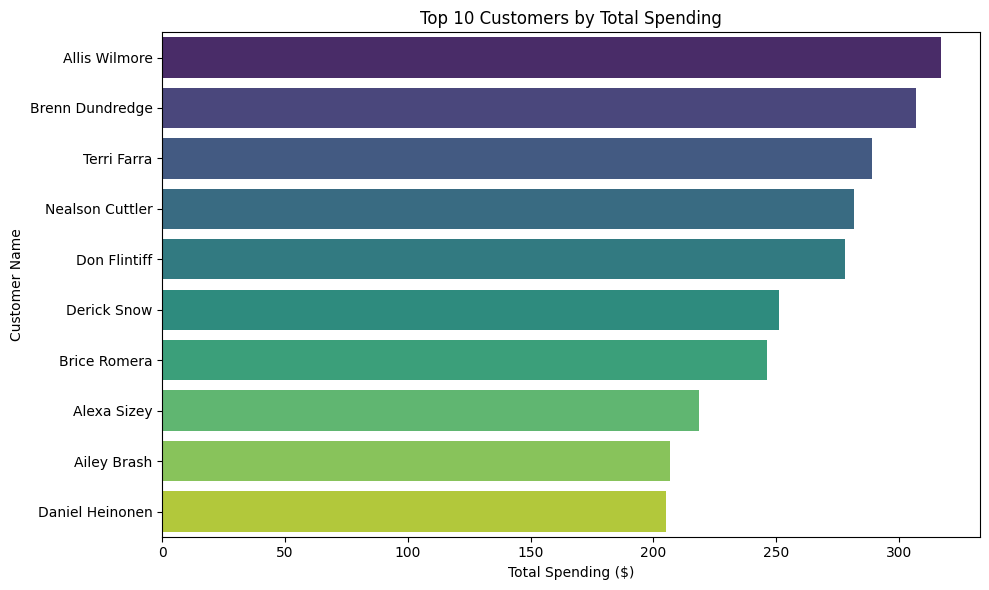

In [72]:
#Top 10 Customers by Total Spending

plt.figure(figsize=(10, 6))

sns.barplot(
    x = top_10.values,
    y = top_10.index,
    palette = "viridis"
)

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Spending ($)")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "01_Top10_Customers.png"), dpi=150)
plt.show()




C:\Users\lenovo\AppData\Local\Temp\ipykernel_10596\2406281793.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<function matplotlib.pyplot.show(close=None, block=None)>

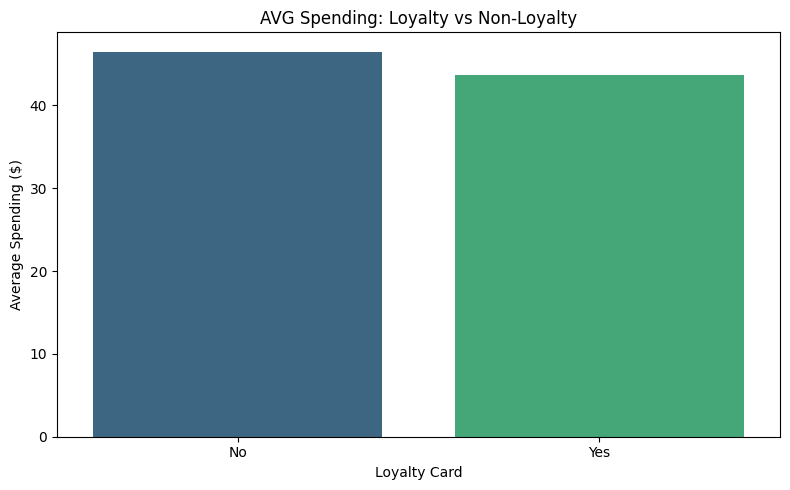

In [76]:
#Loyalty Card Holders vs Non-Holders

plt.figure(figsize=(8,5))

sns.barplot(
    x=loyalty_spending.index,
    y=loyalty_spending.values,
    palette='viridis'
)

plt.title('AVG Spending: Loyalty vs Non-Loyalty')
plt.xlabel('Loyalty Card')
plt.ylabel('Average Spending ($)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT,'02_Loyalty_Spending.png'),dpi=150)
plt.show



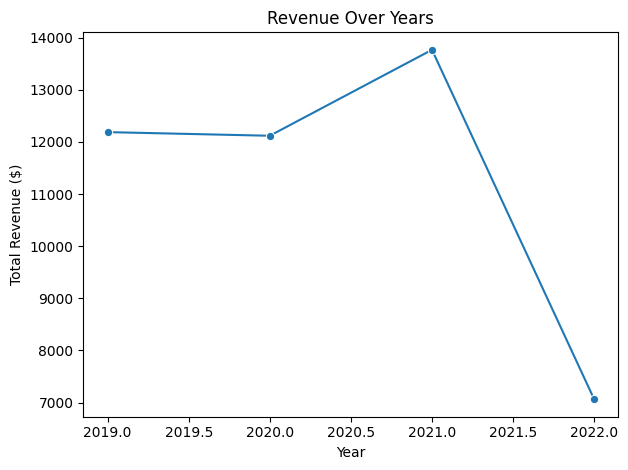

In [77]:
# Revenue Over Years (Time Series)
plt.Figure(figsize=(12,6))
sns.lineplot(
    x=revenue_by_year.index,
    y=revenue_by_year.values,
    marker='o'
)

plt.title('Revenue Over Years')
plt.xlabel('Year')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT,'03_Revenue_Over_Years.png'), dpi=150)
plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_10596\690463870.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


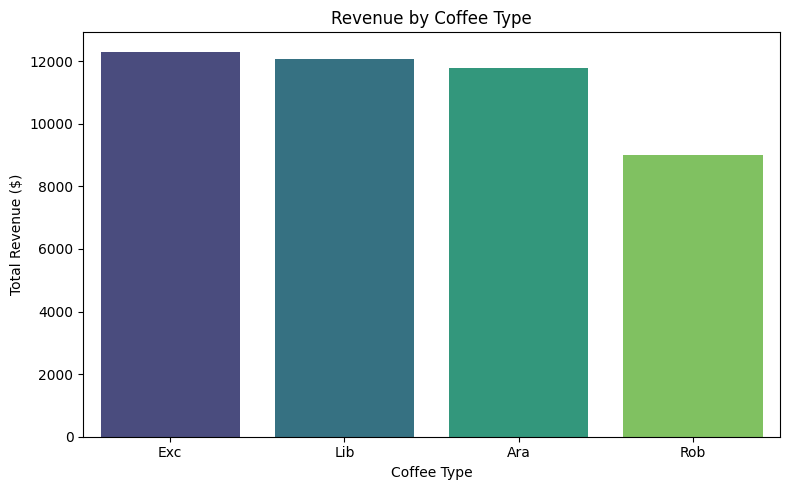

In [78]:
#Revenue by Coffee Type
plt.figure(figsize=(8, 5))

sns.barplot(
    x = coffee_revenue.index,
    y = coffee_revenue.values,
    palette = "viridis"
)

plt.title("Revenue by Coffee Type")
plt.xlabel("Coffee Type")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "04_Revenue_Coffee_Type.png"), dpi=150)
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_10596\2520345978.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


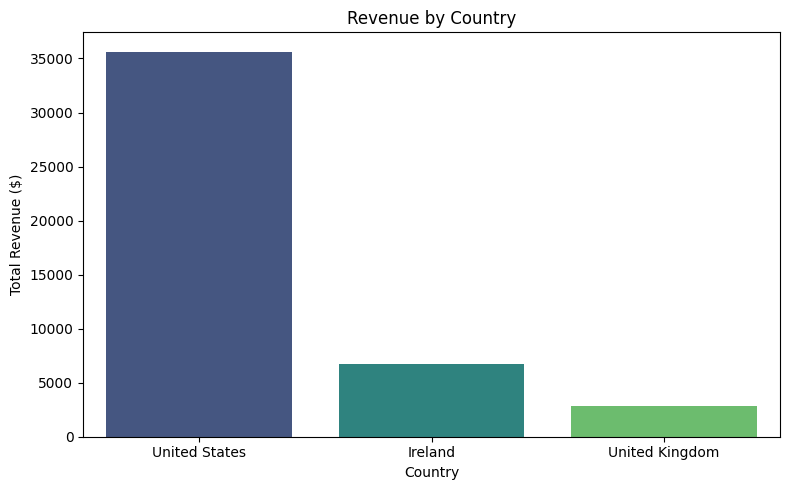

In [79]:
#Revenue by Country

plt.figure(figsize=(8, 5))

sns.barplot(
    x = country_sales.index,
    y = country_sales.values,
    palette = "viridis"
)

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "05_Revenue_Country.png"), dpi=150)
plt.show()



C:\Users\lenovo\AppData\Local\Temp\ipykernel_10596\3929922147.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


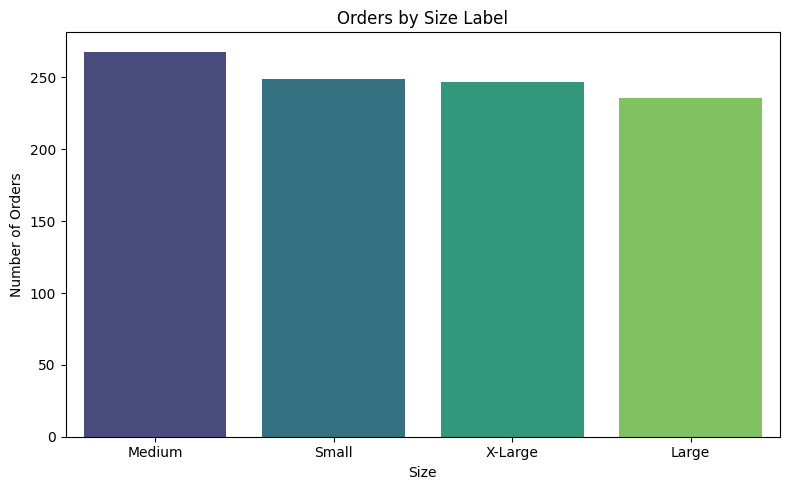

In [80]:
#Most Popular Size

plt.figure(figsize=(8, 5))

sns.barplot(
    x = size_counts.index,
    y = size_counts.values,
    palette = "viridis"
)

plt.title("Orders by Size Label")
plt.xlabel("Size")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "06_Size_Distribution.png"), dpi=150)
plt.show()




C:\Users\lenovo\AppData\Local\Temp\ipykernel_10596\2266216408.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


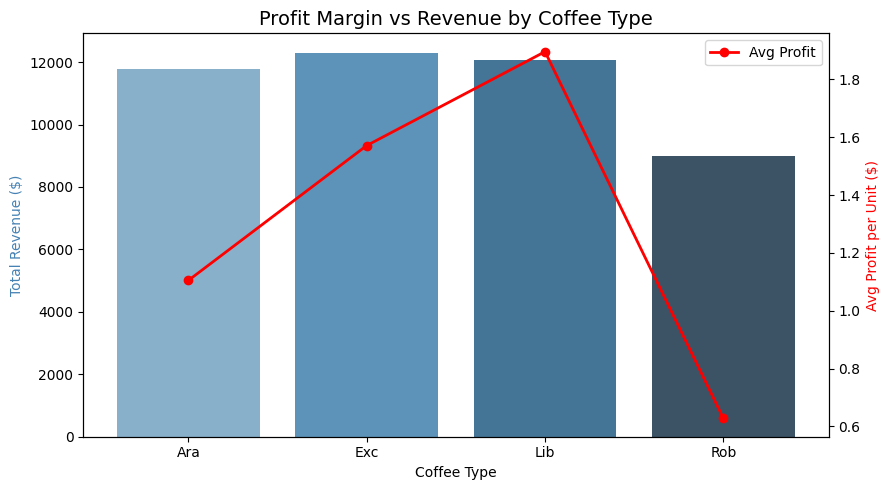

In [81]:
#Profit Margin vs Revenue by Coffee Type
margin_vs_sellers = Sales_df.groupby("Coffee Type").agg(
    Total_Revenue     = ("Total_Order_Value", "sum"),
    Avg_Profit_Margin = ("Profit", "mean")
).reset_index()

# جراف بمحورين Y مختلفين
fig, ax1 = plt.subplots(figsize=(9, 5))

# المحور الأول — الإيرادات
sns.barplot(
    data    = margin_vs_sellers,
    x       = "Coffee Type",
    y       = "Total_Revenue",
    ax      = ax1,
    palette = "Blues_d"
)
ax1.set_ylabel("Total Revenue ($)", color="steelblue")
ax1.set_title("Profit Margin vs Revenue by Coffee Type", fontsize=14)

# المحور التاني — الربح
ax2 = ax1.twinx()
ax2.plot(
    margin_vs_sellers["Coffee Type"],
    margin_vs_sellers["Avg_Profit_Margin"],
    color="red", marker="o", linewidth=2, label="Avg Profit"
)
ax2.set_ylabel("Avg Profit per Unit ($)", color="red")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "07_Profit_vs_Revenue.png"), dpi=150)
plt.show()



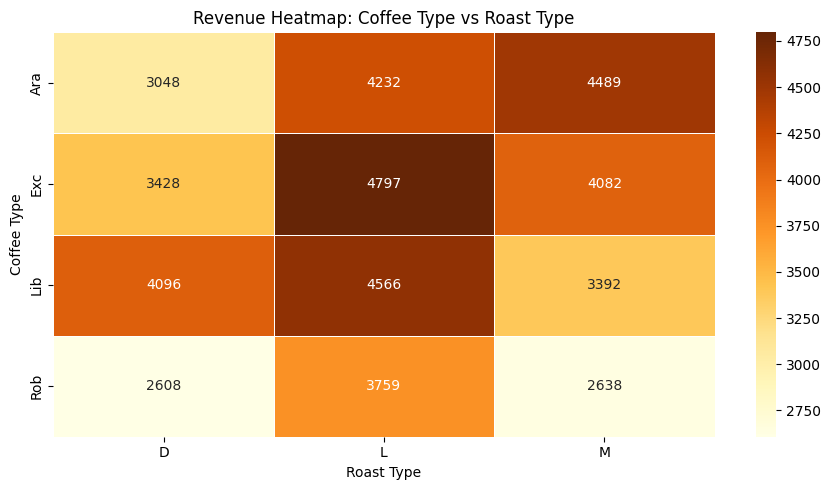

In [83]:
#Heatmap — Coffee Type vs Roast Type

pivot = Sales_df.groupby(
    ["Coffee Type", "Roast Type"]
)["Total_Order_Value"].sum().unstack()

plt.figure(figsize=(9, 5))

sns.heatmap(
    pivot,
    annot      = True,
    fmt        = ".0f",
    cmap       = "YlOrBr",
    linewidths = 0.5
)

plt.title("Revenue Heatmap: Coffee Type vs Roast Type")
plt.xlabel("Roast Type")
plt.ylabel("Coffee Type")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "08_Heatmap_Coffee_Roast.png"), dpi=150)
plt.show()

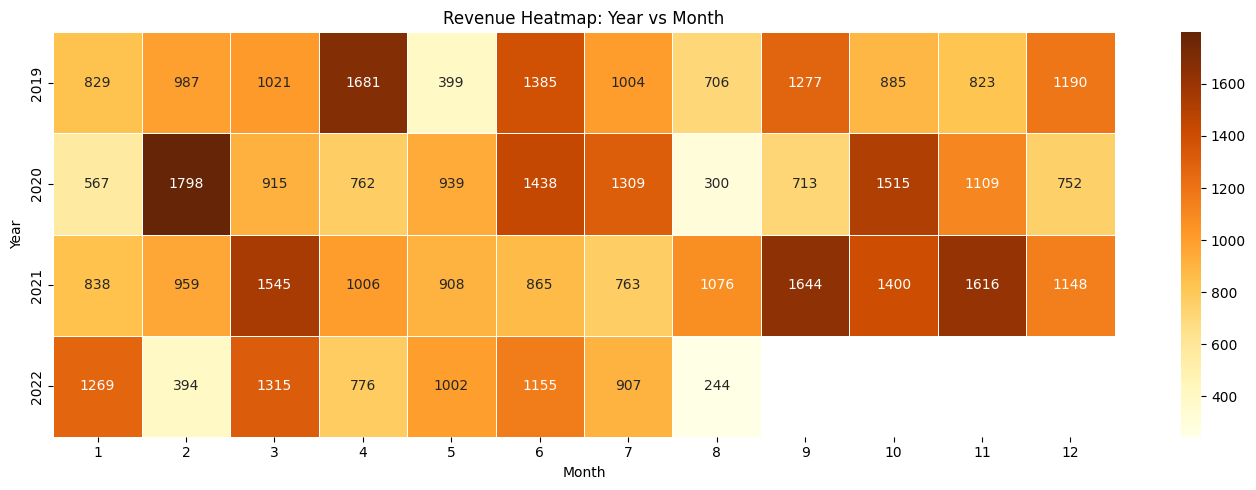

In [84]:
#Heatmap — Revenue by Year vs Month

year_month = Sales_df.groupby(
    ["Year", "Month"]
)["Total_Order_Value"].sum().unstack()

plt.figure(figsize=(14, 5))

sns.heatmap(
    year_month,
    annot      = True,
    fmt        = ".0f",
    cmap       = "YlOrBr",
    linewidths = 0.5
)

plt.title("Revenue Heatmap: Year vs Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "09_Heatmap_Year_Month.png"), dpi=150)
plt.show()

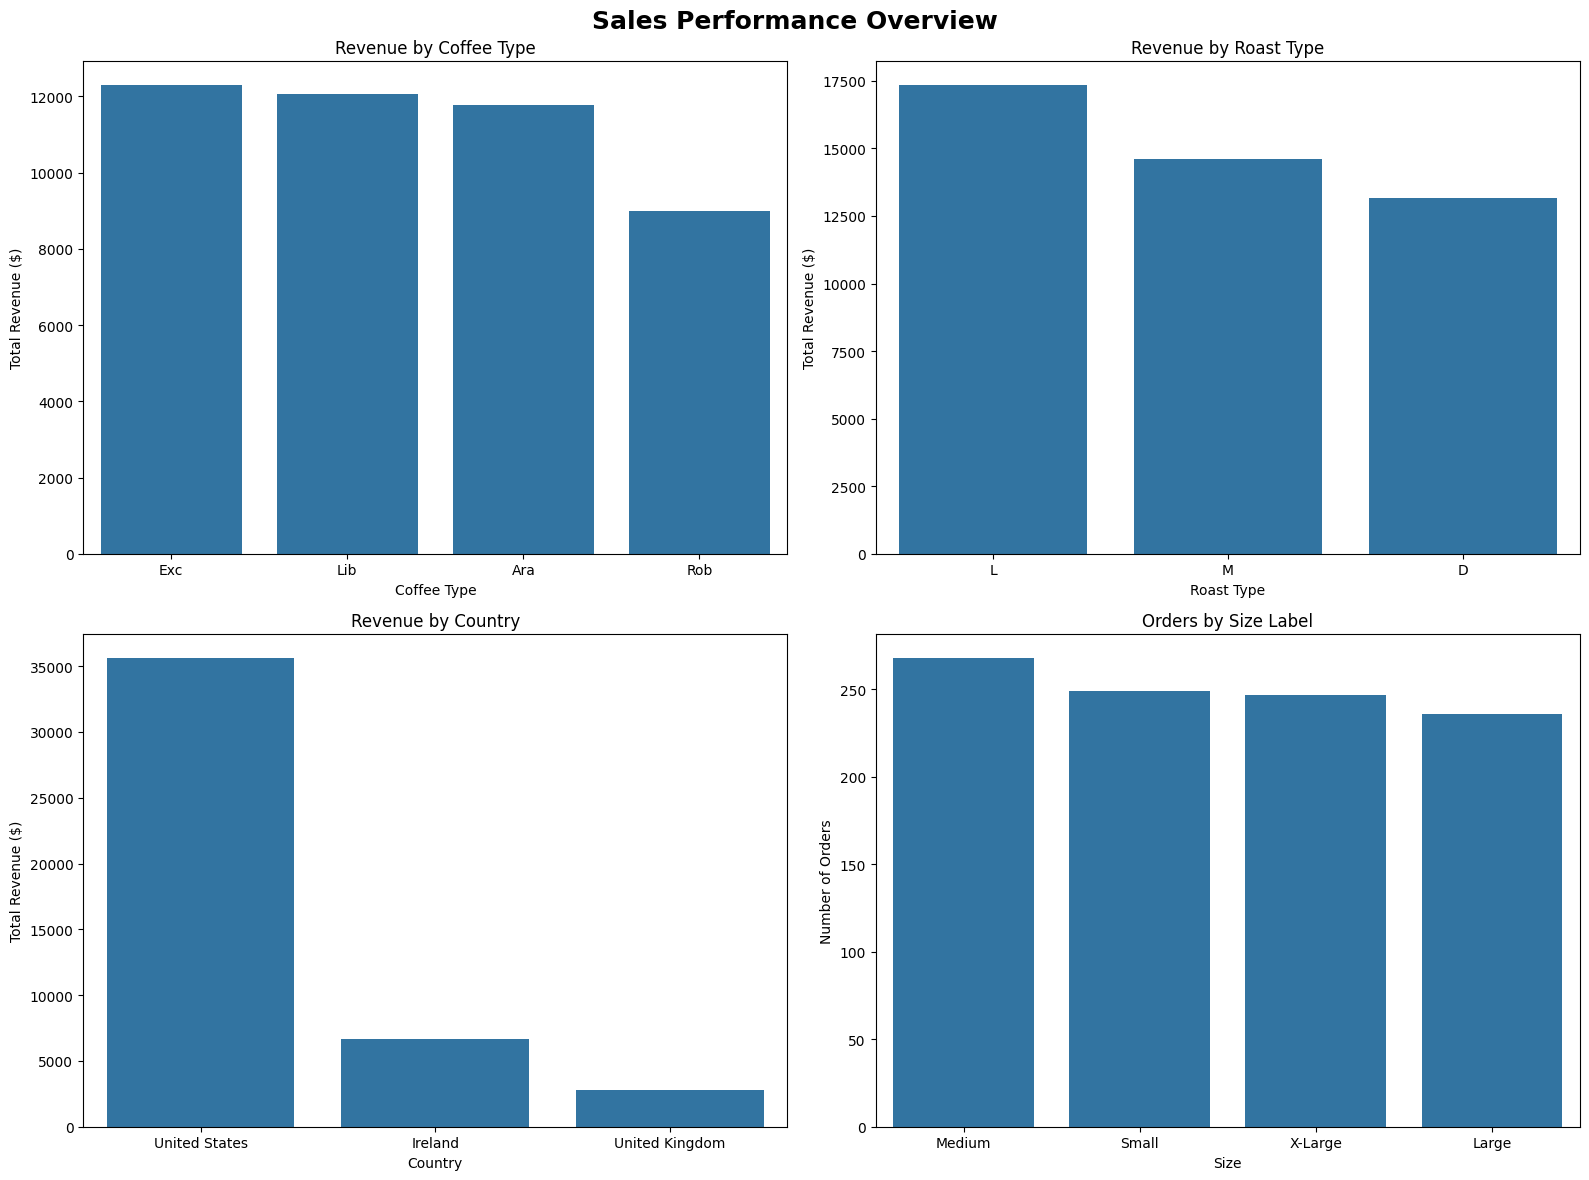

In [85]:
#Sales Performance Overview (Multi-Chart)
# بنعمل figure فيها 4 جرافات في نفس الوقت
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Sales Performance Overview", fontsize=18, fontweight="bold")

# الجراف 1 — Revenue by Coffee Type (فوق شمال)
sns.barplot(
    x  = coffee_revenue.index,
    y  = coffee_revenue.values,
    ax = axes[0, 0]
)
axes[0, 0].set_title("Revenue by Coffee Type")
axes[0, 0].set_xlabel("Coffee Type")
axes[0, 0].set_ylabel("Total Revenue ($)")

# الجراف 2 — Revenue by Roast Type (فوق يمين)
sns.barplot(
    x  = roast_revenue.index,
    y  = roast_revenue.values,
    ax = axes[0, 1]
)
axes[0, 1].set_title("Revenue by Roast Type")
axes[0, 1].set_xlabel("Roast Type")
axes[0, 1].set_ylabel("Total Revenue ($)")

# الجراف 3 — Revenue by Country (تحت شمال)
sns.barplot(
    x  = country_sales.index,
    y  = country_sales.values,
    ax = axes[1, 0]
)
axes[1, 0].set_title("Revenue by Country")
axes[1, 0].set_xlabel("Country")
axes[1, 0].set_ylabel("Total Revenue ($)")

# الجراف 4 — Orders by Size (تحت يمين)
sns.barplot(
    x  = size_counts.index,
    y  = size_counts.values,
    ax = axes[1, 1]
)
axes[1, 1].set_title("Orders by Size Label")
axes[1, 1].set_xlabel("Size")
axes[1, 1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "10_Overview.png"), dpi=150)
plt.show()

In [ ]:
# Summarize all findings in a clear report for non-technical stakeholders

print("=" * 55)
print("      COFFEE BEAN SALES — FINAL SUMMARY")
print("=" * 55)

print(f"\nTotal Revenue       : ${Sales_df['Total_Order_Value'].sum():,.2f}")
print(f"Total Orders        : {len(Sales_df):,}")
print(f"Unique Customers    : {Sales_df['Customer ID'].nunique()}")

print(f"\nTop Country         : {country_sales.idxmax()}")
print(f"Top Coffee Type     : {coffee_revenue.idxmax()}")
print(f"Most Popular Size   : {size_counts.idxmax()}")
print(f"Most Popular Roast  : {roast_revenue.idxmax()}")

print("\n" + "=" * 55)

      COFFEE BEAN SALES — FINAL SUMMARY

Total Revenue       : $45,134.25
Total Orders        : 1,000
Unique Customers    : 913

Top Country         : United States
Top Coffee Type     : Exc
Most Popular Size   : Medium
Most Popular Roast  : L

